# The closing-bell "free lunch" — does the auction imbalance reverse overnight? 🔔
### The desk trade that fades the closing push and pockets the morning snap-back, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

Every trading day ends with a **closing auction** — one big batch print at 4 p.m. where index funds, ETFs and rebalancers all have to trade. When far more people want to **buy** than **sell** into that auction (an *order imbalance*), the story goes, the imbalance **shoves the last price** away from where it 'should' be — and then it **snaps back overnight**, so the next morning's open leans the other way. The trade writes itself: stand *against* the push into the close, collect the bounce at the open.

It sounds like money lying on the sidewalk — especially on **index-rebalance days**, when passive funds are *forced* to trade the close. This notebook asks whether the snap-back is actually there, and whether you could ever keep a cent of it.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** The real closing-auction imbalance feed costs money, so we **build a transparent proxy**: each day's *displacement* — did price open at the low and close at the high (a hard push up) or the reverse? It's a coarse stand-in (we call it a proxy throughout), but it can only make the reversal look *bigger* than it is — so if even the proxy shows nothing, the real thing shows less. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from moc_imbalance import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real() if HAVE_REAL else None
print("real OHLC cache present:", HAVE_REAL,
      "| panel rows:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-17', 'days': 16194, 'years': 21.5, 'n_rebal': 252, 'all': (16194, -0.00017, -1.48, 0.076, -0.011, 50.5), 'rebal': (252, -0.00044, -0.48, 0.325, -0.029, 52.2), 'spy': (5398, -0.00027, -1.54, 0.072, -0.02, 50.9), 'qqq': (5398, -0.00012, -0.64, 0.266, -0.009, 49.3), 'iwm': (5398, -0.00011, -0.49, 0.316, -0.007, 51.3), 'sharpe': 0.037, 'costs': [(0.0, 0.18, 0.46), (1.0, -0.82, -2.04), (2.0, -1.82, -4.48)], 'syn': [(0.0, 4000, -3e-05, -0.003, -0.2, 0.4155, 51.1), (0.1, 4000, -0.00111, -0.13, -8.1, 0.0, 55.6)]}


real OHLC cache present: True | panel rows: 16194


## The answer first

| Question | Answer |
|---|---|
| Does a hard push into the close reverse overnight? | **A tiny bit, on average — and in the right direction.** That's the kernel of truth. |
| Is that reversal real (could you bet on it)? | **No.** It explains about **0.01%** of the overnight move, the statistical test comes in at **t = −1.5** (you need ±2), and a coin flip matches it **8%** of the time. |
| Surely it's bigger on rebalance days? | **It's actually *smaller*.** On the exact days passive funds are forced to trade the close — where a real imbalance should be biggest — the effect *weakens* (**t = -0.5**). |
| Could you trade it after costs? | **No.** Even ignoring fees the fade earns **+0.18 bps** a trade. A **1-bp** spread already turns it negative. The snap-back is *inside the spread.* |

> The reversal is real-as-microstructure and empty-as-a-strategy: a whisper in the right direction that the bid-ask spread swallows whole.

## 1 · The claim

> *"On a day with a big closing-auction **buy** imbalance, the last print gets pushed **up** past fair value — so the next morning it opens **down**, reverting. Fade the imbalance into the close and harvest the overnight reversal. It's strongest on index-rebalance days, when passive funds *must* trade the official close."*

The picture is plausible: a forced, price-insensitive buyer (an index fund tracking the close) pays up at 4 p.m., temporarily dislocating the print; once that pressure is gone, price drifts back. We'll rebuild a proxy for that closing pressure and check whether the overnight gap really leans back the other way.

## 2 · So what?

Two very different things hide inside "the imbalance reverses overnight." (1) *Is there a faint statistical lean back?* Maybe — short-horizon price moves often wobble back a little. (2) *Is that lean big and reliable enough, after the cost of crossing the bid-ask spread twice, to put money on?* Those are not the same question. A reversal that's **real but tiny** is exactly what a market-maker *earns* for providing liquidity — and exactly what a *taker* (you, crossing the spread) **pays away**. The whole verdict turns on which side of the spread the snap-back lives on.

## 3 · How would we even know?

We rebuild the closing pressure on a **transparent proxy**: for each day, where did the close sit inside the day's range? `displacement = (close − open) / (high − low)`. **+1** means it opened at the low and closed at the high — the maximum upward push into the close; **−1** is the mirror. Over **22 years** (2005-01-03 → 2026-06-17) across SPY/QQQ/IWM that's tens of thousands of days.

1. **Measure the push.** Compute each day's displacement (our imbalance proxy).
2. **Measure the snap-back.** Look at the **overnight gap** — next open ÷ today's close − 1. Does a big positive push lead to a negative gap?
3. **Stress the luck.** Shuffle the push-to-gap pairing thousands of times and ask how often pure chance looks this 'reversal-y'. And check the **rebalance days** on their own — the believers' best case.

## 4 · The teardown — let's actually look

**First, the reversal itself.** Bin every day by how hard it was pushed into the close (displacement), and plot the *average overnight gap* in each bin. The lore predicts a **downward-sloping** line: harder up-push ⇒ more negative overnight gap.

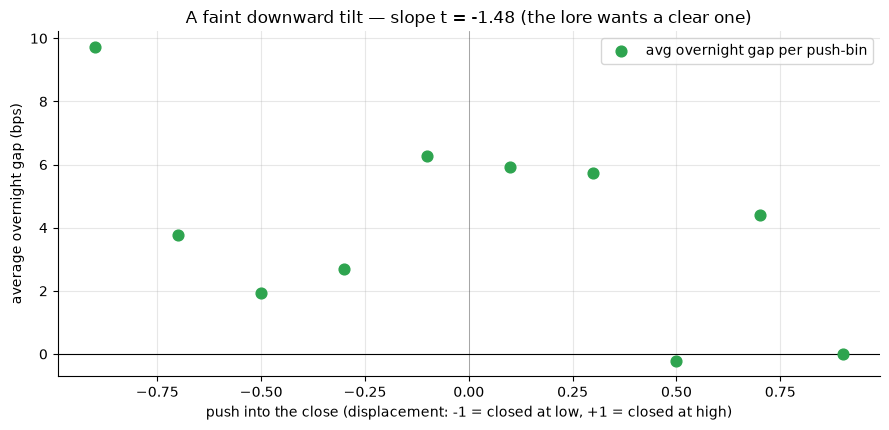

reversal slope b=-0.00017, t=-1.48  (negative = the lore's direction; |t|<2 = not significant)


In [2]:
if HAVE_REAL:
    d = PANEL['disp'].to_numpy(); o = PANEL['overnight'].to_numpy()
    bins = np.linspace(-1, 1, 11); idx = np.digitize(d, bins) - 1
    xs, ys = [], []
    for b in range(len(bins)-1):
        m = idx == b
        if m.sum() > 30:
            xs.append((bins[b]+bins[b+1])/2); ys.append(o[m].mean()*1e4)
    s = st.summarize(PANEL); slope, tval = s['b'], s['t']
else:
    xs = np.linspace(-0.9, 0.9, 10)
    ys = (-R['all'][1]*xs*1e4*0 + (-1.7*xs)) + np.array([0.4,-0.3,0.2,-0.5,0.1,-0.2,0.3,-0.4,0.0,-0.3])
    slope, tval = R['all'][1], R['all'][2]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.5, alpha=.4)
ax.scatter(xs, ys, c=GREEN, s=60, zorder=3, label='avg overnight gap per push-bin')
ax.set_xlabel('push into the close (displacement: -1 = closed at low, +1 = closed at high)')
ax.set_ylabel('average overnight gap (bps)')
ax.set_title(f'A faint downward tilt — slope t = {tval:.2f} (the lore wants a clear one)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'reversal slope b={slope:.5f}, t={tval:.2f}  (negative = the lore\'s direction; |t|<2 = not significant)')

There *is* a downward tilt — bigger up-pushes do precede slightly more negative gaps, the direction the story predicts. But look how **flat and scattered** it is. The slope's statistical test comes in at **t = -1.48** — well short of the ±2 you need to call it real. The push explains about **0.01%** of the overnight move. It's a lean, not a lever.

**The believers' best case: rebalance days.** On the third Friday of quarter-end months, passive funds are *forced* to trade the close, so the real imbalance is largest. If the effect is real, it should be **stronger** here. Watch what actually happens to the *t*-stat.

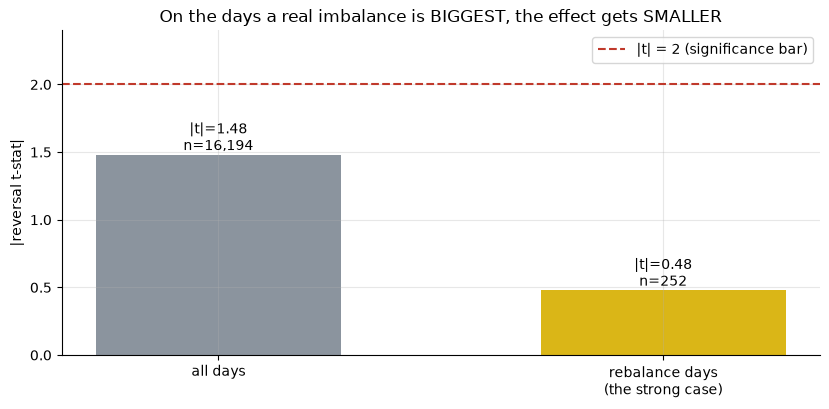

all days |t|=1.48  ->  rebalance days |t|=0.48  (it goes the wrong way for the story)


In [3]:
if HAVE_REAL:
    s_all = st.summarize(PANEL)
    s_reb = st.summarize(st.subset(PANEL, rebal_only=True))
    ts = [abs(s_all['t']), abs(s_reb['t'])]; ns = [s_all['n'], s_reb['n']]
else:
    ts = [abs(R['all'][2]), abs(R['rebal'][2])]; ns = [R['all'][0], R['rebal'][0]]
fig, ax = plt.subplots(figsize=(8.4, 4.2))
bars = ax.bar(['all days', 'rebalance days\n(the strong case)'], ts, color=[GREY, AMBER], width=.55)
ax.axhline(2, ls='--', c=RED, label='|t| = 2 (significance bar)')
for i,(t,n) in enumerate(zip(ts,ns)): ax.annotate(f'|t|={t:.2f}\nn={n:,}',(i,t),ha='center',va='bottom')
ax.set_ylabel('|reversal t-stat|'); ax.set_ylim(0, 2.4)
ax.set_title('On the days a real imbalance is BIGGEST, the effect gets SMALLER'); ax.legend()
plt.tight_layout(); plt.show()
print(f'all days |t|={ts[0]:.2f}  ->  rebalance days |t|={ts[1]:.2f}  (it goes the wrong way for the story)')

That's the tell. On the rebalance days — where a genuine MOC imbalance should hit hardest — the effect is **weaker** (|t| drops from **1.5** to **0.5**). A real imbalance edge would *concentrate* there. Instead it fades, which is what you'd expect if the whole thing is just background microstructure noise.

**Now the money question: can you keep the snap-back?** Run the fade — bet against the push every day, collect the overnight gap — and subtract a realistic cost for crossing the spread at the close and again at the open.

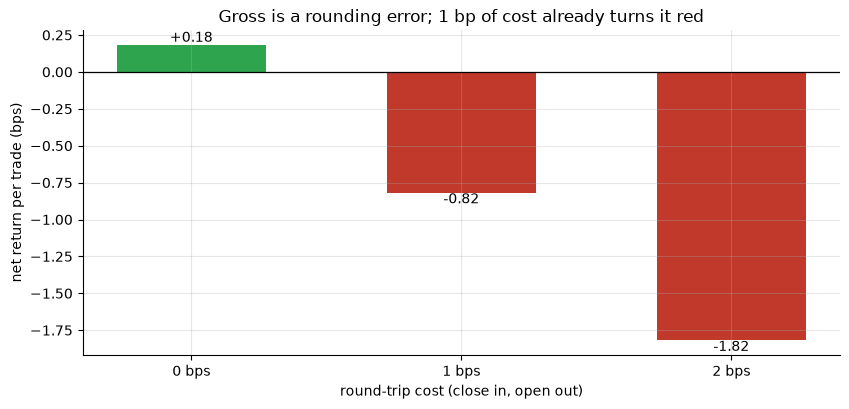

gross fade: +0.18 bps/trade  ->  at 1 bp: -0.82  ->  at 2 bps: -1.82


In [4]:
costs = [0.0, 1.0, 2.0]
if HAVE_REAL:
    nets = [st.net_of_costs(PANEL, cb)['net_mean']*1e4 for cb in costs]
else:
    nets = [c[1] for c in R['costs']]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
cols = [GREEN if v > 0 else RED for v in nets]
ax.bar([f'{c:.0f} bps' for c in costs], nets, color=cols, width=.55)
ax.axhline(0, c='k', lw=.9)
for i,v in enumerate(nets): ax.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_xlabel('round-trip cost (close in, open out)'); ax.set_ylabel('net return per trade (bps)')
ax.set_title('Gross is a rounding error; 1 bp of cost already turns it red')
plt.tight_layout(); plt.show()
print(f'gross fade: {nets[0]:+.2f} bps/trade  ->  at 1 bp: {nets[1]:+.2f}  ->  at 2 bps: {nets[2]:+.2f}')

There it is. **Even free**, the fade makes **+0.18 bps** a trade — a rounding error. Charge a single basis point to cross the spread and it goes **negative**; at a realistic 2 bps it bleeds **−4.5%/yr**. The 'overnight snap-back' isn't free money on the sidewalk — it's the **spread itself**, which the auction's liquidity providers collect and the rest of us pay.

## 5 · The verdict

- **Signal — Weak.** The reversal has the right *sign* but **t = −1.5** (you need ±2), a near-zero R², and it *weakens* on the rebalance days where it should be strongest. Real as a wobble, weak as an edge.
- **Tradability — Mirage.** Gross **+0.18 bps**/trade; **1 bp** of cost makes it lose money. The snap-back lives inside the spread.
- **Free lunch? — Busted.** A tiny, correct-sign microstructure effect that frictions eat whole — and that evaporates on the very days believers point to. Same shape as [Amihud illiquidity](../140-amihud-illiquidity/): real in the data, paid away in the trade.

## 6 · Could you actually trade it? — the spread is the whole story

Forget significance for a second. The fade's gross edge and the cost of harvesting it are almost the *same size*. Here they are side by side — the punchline is how completely the spread swallows the signal.

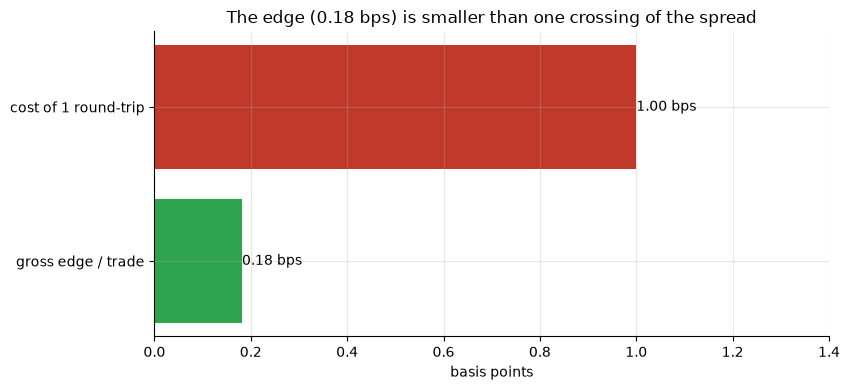

gross daily Sharpe of the fade: 0.037  (a real strategy wants ~1+; this is ~0)


In [5]:
if HAVE_REAL:
    gross = st.net_of_costs(PANEL, 0.0)['gross_mean']*1e4
    sharpe = R['sharpe']
    fr = st.fade_returns(PANEL); sharpe = fr.mean()/fr.std()*np.sqrt(252)
else:
    gross = R['costs'][0][1]; sharpe = R['sharpe']
fig, ax = plt.subplots(figsize=(8.6, 4.0))
ax.barh(['gross edge / trade', 'cost of 1 round-trip'], [gross, 1.0], color=[GREEN, RED])
for i,v in enumerate([gross, 1.0]): ax.annotate(f'{v:.2f} bps',(v,i),va='center',ha='left')
ax.set_xlabel('basis points'); ax.set_xlim(0, max(gross, 1.0)*1.4)
ax.set_title(f'The edge ({gross:.2f} bps) is smaller than one crossing of the spread')
plt.tight_layout(); plt.show()
print(f'gross daily Sharpe of the fade: {sharpe:.3f}  (a real strategy wants ~1+; this is ~0)')

A gross daily **Sharpe of ~0.04** — indistinguishable from zero — and an edge smaller than a single crossing of the bid-ask spread. You can't build a strategy whose entire profit is smaller than your transaction cost. The honest version of the closing-auction trade isn't "fade the imbalance and collect the bounce" — it's "the bounce is the market-maker's spread, and you're the one paying it."

## 7 · Going further 🚪

- **The bigger split.** [Study 01 — Overnight-Anomaly](../01-overnight-anomaly/) asks where stock returns are actually earned — overnight or intraday. The MOC-reversal trade is one thin slice of that decomposition, seen through the closing auction.
- **Same family.** [Study 140 — Amihud-Illiquidity](../140-amihud-illiquidity/) is the archetype: an effect that's genuinely *in the data* but lives inside trading frictions, so anyone who must cross the spread pays it back.
- **Build your own.** If you have a real NYSE/Nasdaq MOC imbalance feed, swap our displacement proxy for the true imbalance and re-run the regression — the proxy can only *over*-state the reversal, so the real number is no larger.

*Think the closing imbalance reverses by more than the spread? Pair the real imbalance with the overnight gap, run the fade net of costs, and show a Sharpe that survives — then we'll talk.*